In [ ]:
# MODULE 7 — VISUALISATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD CLEANED DATASETS
# ============================================================


customers = pd.read_csv(
    "cleaned_saas_customers.csv"
)

subscriptions = pd.read_csv(
    "cleaned_saas_subscriptions.csv"
)

usage = pd.read_csv(
    "cleaned_saas_usage.csv"
)

tickets = pd.read_csv(
    "cleaned_saas_tickets.csv"
)

print("=" * 70)
print("MODULE 5 — STATISTICS")
print("=" * 70)

print("\nDatasets loaded successfully.")

MODULE 5 — STATISTICS

Datasets loaded successfully.


In [ ]:
#============================================================
# 2. CONVERT DATES
# ============================================================

customers["SignupDate"] = pd.to_datetime(
    customers["SignupDate"],
    errors="coerce"
)

subscriptions["StartDate"] = pd.to_datetime(
    subscriptions["StartDate"],
    errors="coerce"
)

subscriptions["EndDate"] = pd.to_datetime(
    subscriptions["EndDate"],
    errors="coerce"
)

usage["Month"] = pd.to_datetime(
    usage["Month"],
    errors="coerce"
)

tickets["OpenedDate"] = pd.to_datetime(
    tickets["OpenedDate"],
    errors="coerce"
)


# ============================================================
# 3. CONVERT NUMERIC COLUMNS
# ============================================================

subscriptions["MRR"] = pd.to_numeric(
    subscriptions["MRR"],
    errors="coerce"
)

subscriptions["Seats"] = pd.to_numeric(
    subscriptions["Seats"],
    errors="coerce"
)

usage["Logins"] = pd.to_numeric(
    usage["Logins"],
    errors="coerce"
)

usage["ActiveUsers"] = pd.to_numeric(
    usage["ActiveUsers"],
    errors="coerce"
)

usage["APICalls"] = pd.to_numeric(
    usage["APICalls"],
    errors="coerce"
)

usage["SessionMinutes"] = pd.to_numeric(
    usage["SessionMinutes"],
    errors="coerce"
)

tickets["ResolutionHours"] = pd.to_numeric(
    tickets["ResolutionHours"],
    errors="coerce"
)

tickets["SatisfactionScore"] = pd.to_numeric(
    tickets["SatisfactionScore"],
    errors="coerce"
)

In [ ]:
# ============================================================
# 4. CREATE CUSTOMER-LEVEL USAGE
# ============================================================

customer_usage = (
    usage
    .groupby("CustomerID")
    .agg(
        Total_Logins=("Logins", "sum"),
        Total_ActiveUsers=("ActiveUsers", "sum"),
        Total_APICalls=("APICalls", "sum"),
        Total_SessionMinutes=("SessionMinutes", "sum")
    )
    .reset_index()
)

# ============================================================
# 5. CREATE CUSTOMER-LEVEL TICKET SUMMARY
# ============================================================

customer_tickets = (
    tickets
    .groupby("CustomerID")
    .agg(
        Ticket_Count=("TicketID", "nunique"),
        Average_Satisfaction=("SatisfactionScore", "mean"),
        Average_ResolutionHours=("ResolutionHours", "mean")
    )
    .reset_index()
)


# ============================================================
# 6. CREATE CUSTOMER-LEVEL MRR
# ============================================================

customer_mrr = (
    subscriptions
    .groupby("CustomerID")
    .agg(
        Total_MRR=("MRR", "sum"),
        Total_Seats=("Seats", "sum")
    )
    .reset_index()
)

In [ ]:
# ============================================================
# 7. CREATE MASTER CUSTOMER VIEW
# ============================================================

customer_view = customers.merge(
    customer_mrr,
    on="CustomerID",
    how="left"
)

customer_view = customer_view.merge(
    customer_usage,
    on="CustomerID",
    how="left"
)

customer_view = customer_view.merge(
    customer_tickets,
    on="CustomerID",
    how="left"
)


metric_columns = [
    "Total_MRR",
    "Total_Seats",
    "Total_Logins",
    "Total_ActiveUsers",
    "Total_APICalls",
    "Total_SessionMinutes",
    "Ticket_Count"
]

for column in metric_columns:
    customer_view[column] = (
        customer_view[column]
        .fillna(0)
    )


    # ============================================================
# 8. CREATE CHURN FLAG
# ============================================================

churned_customers = (
    subscriptions[
        subscriptions["Status"]
        .astype("string")
        .str.strip()
        .str.lower()
        == "churned"
    ]["CustomerID"]
    .dropna()
    .unique()
)

customer_view["Churn_Status"] = np.where(
    customer_view["CustomerID"].isin(
        churned_customers
    ),
    "Churned",
    "Retained"
)

print("\nCustomer churn status created.")

print(
    customer_view["Churn_Status"]
    .value_counts()
)



Customer churn status created.
Churn_Status
Retained    300
Churned     120
Name: count, dtype: int64


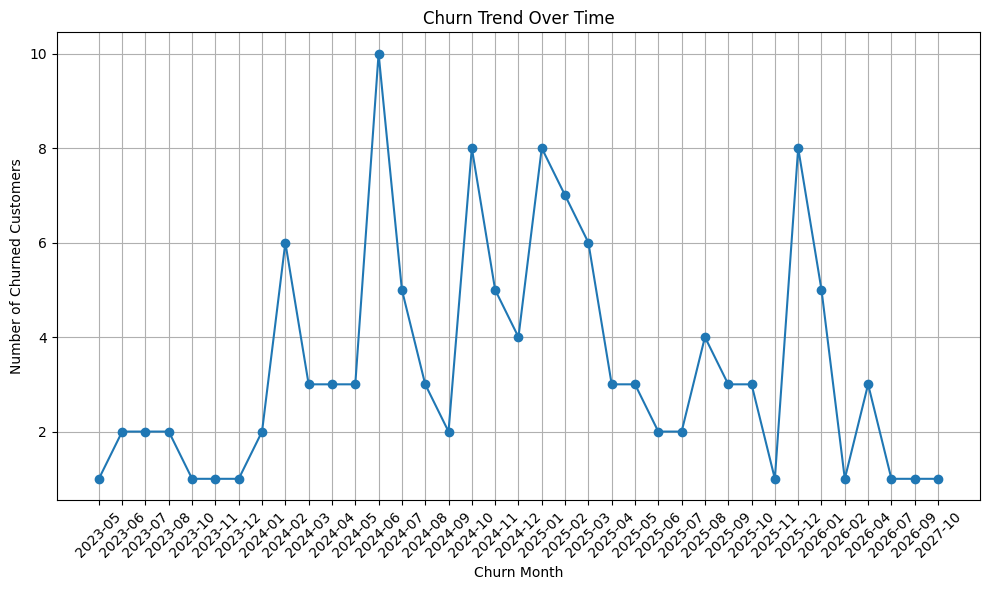

Insight: The highest monthly churn was 10 customers in 2024-06.


In [ ]:
# ============================================================
# CHART 1 — CHURN TREND OVER TIME
# ============================================================

subscriptions["ChurnMonth"] = (
    subscriptions["EndDate"]
    .dt.to_period("M")
)

churn_trend = (
    subscriptions[
        subscriptions["Status"]
        .astype("string")
        .str.strip()
        .str.lower()
        == "churned"
    ]
    .dropna(subset=["ChurnMonth"])
    .groupby("ChurnMonth")
    ["CustomerID"]
    .nunique()
    .reset_index(name="Churned_Customers")
)

churn_trend["ChurnMonth"] = (
    churn_trend["ChurnMonth"]
    .astype(str)
)

plt.figure(figsize=(10, 6))

plt.plot(
    churn_trend["ChurnMonth"],
    churn_trend["Churned_Customers"],
    marker="o"
)

plt.title("Churn Trend Over Time")
plt.xlabel("Churn Month")
plt.ylabel("Number of Churned Customers")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

if len(churn_trend) > 0:

    highest_churn = churn_trend.loc[
        churn_trend["Churned_Customers"].idxmax()
    ]

    print(
        "Insight: The highest monthly churn was",
        int(highest_churn["Churned_Customers"]),
        "customers in",
        highest_churn["ChurnMonth"] + "."
    )

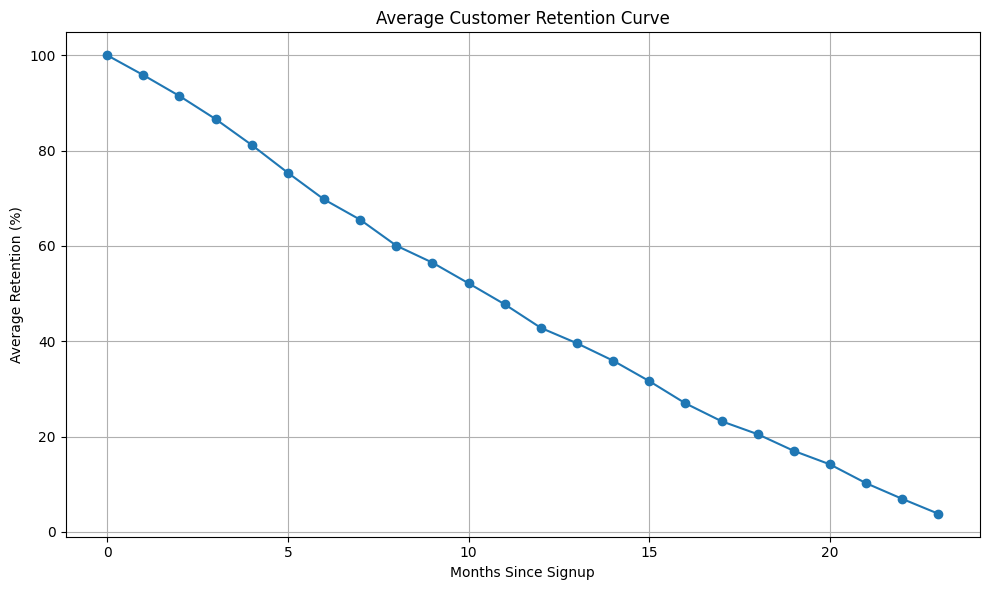

Insight: Average retention changed from 100.0% at month 0 to 3.8% at month 23.


In [ ]:

# ============================================================
# CHART 2 — RETENTION CURVE
# ============================================================

customers["CohortMonth"] = (
    customers["SignupDate"]
    .dt.to_period("M")
)

usage["ActivityMonth"] = (
    usage["Month"]
    .dt.to_period("M")
)

customer_activity = (
    usage[
        ["CustomerID", "ActivityMonth"]
    ]
    .dropna()
    .drop_duplicates()
)

cohort_activity = customer_activity.merge(
    customers[
        ["CustomerID", "CohortMonth"]
    ],
    on="CustomerID",
    how="left"
)

cohort_activity = cohort_activity.dropna(
    subset=[
        "CohortMonth",
        "ActivityMonth"
    ]
)

cohort_activity["CohortIndex"] = (
    (
        cohort_activity["ActivityMonth"].dt.year
        -
        cohort_activity["CohortMonth"].dt.year
    ) * 12
    +
    (
        cohort_activity["ActivityMonth"].dt.month
        -
        cohort_activity["CohortMonth"].dt.month
    )
)

cohort_activity = cohort_activity[
    cohort_activity["CohortIndex"] >= 0
]

cohort_sizes = (
    customers
    .groupby("CohortMonth")
    ["CustomerID"]
    .nunique()
)

active_customers = (
    cohort_activity
    .groupby(
        ["CohortMonth", "CohortIndex"]
    )
    ["CustomerID"]
    .nunique()
)

retention_table = (
    active_customers
    .unstack(fill_value=0)
)

retention_rate = (
    retention_table
    .divide(cohort_sizes, axis=0)
    * 100
)

average_retention = (
    retention_rate
    .mean(axis=0)
)

plt.figure(figsize=(10, 6))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker="o"
)

plt.title("Average Customer Retention Curve")
plt.xlabel("Months Since Signup")
plt.ylabel("Average Retention (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

if len(average_retention) > 0:

    first_retention = average_retention.iloc[0]

    last_retention = average_retention.iloc[-1]

    print(
        f"Insight: Average retention changed from "
        f"{first_retention:.1f}% at month "
        f"{average_retention.index[0]} to "
        f"{last_retention:.1f}% at month "
        f"{average_retention.index[-1]}."
    )

In [ ]:
# ============================================================
# CHART 3 — CHURN BY SEGMENT
# ============================================================

# Check whether Segment exists
print("customer_view columns:")
print(customer_view.columns.tolist())

if "Segment" not in customer_view.columns:

    print("\nERROR: 'Segment' column is not available in customer_view.")

else:

    segment_churn = (
        customer_view
        .groupby("Segment")["Churn_Status"]
        .apply(
            lambda x: (x == "Churned").mean() * 100
        )
        .reset_index(
            name="Churn_Rate"
        )
    )

    plt.figure(figsize=(9, 6))

    plt.bar(
        segment_churn["Segment"],
        segment_churn["Churn_Rate"]
    )

    plt.title("Churn Rate by Segment")
    plt.xlabel("Customer Segment")
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

    # One-line insight
    if len(segment_churn) > 0:

        highest_segment = segment_churn.loc[
            segment_churn["Churn_Rate"].idxmax()
        ]

        print(
            f"Insight: The {highest_segment['Segment']} segment "
            f"had the highest churn rate at "
            f"{highest_segment['Churn_Rate']:.1f}%."
        )

customer_view columns:
['CustomerID', 'CompanyName', 'Industry', 'Country', 'City', 'EmployeeCount', 'SignupDate', 'AcquisitionChannel', 'Total_MRR', 'Total_Seats', 'Total_Logins', 'Total_ActiveUsers', 'Total_APICalls', 'Total_SessionMinutes', 'Ticket_Count', 'Average_Satisfaction', 'Average_ResolutionHours', 'Churn_Status']

ERROR: 'Segment' column is not available in customer_view.


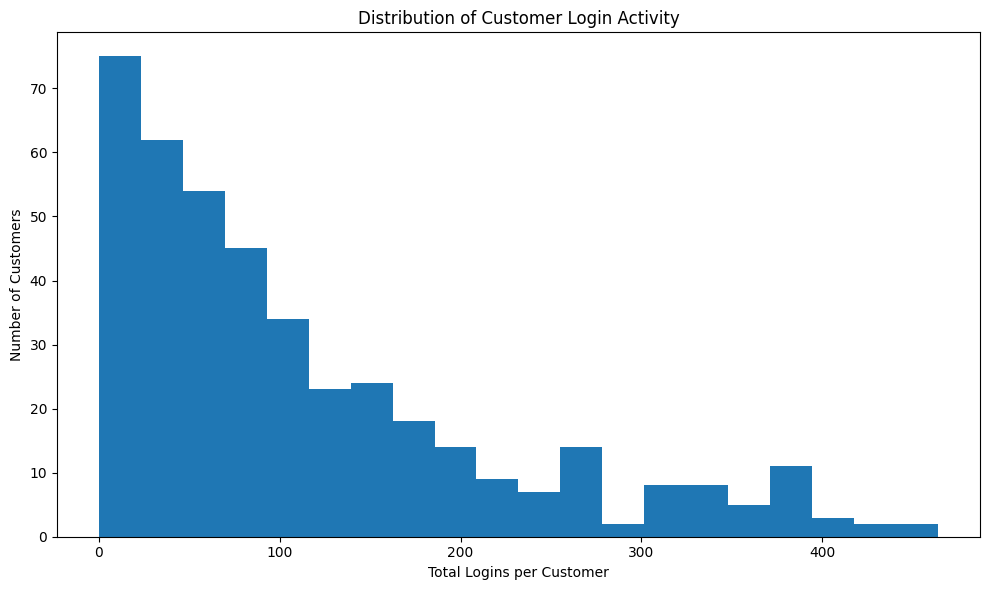

Insight: The median customer recorded 82.0 total logins.


In [ ]:

# ============================================================
# CHART 4 — USAGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    customer_view["Total_Logins"],
    bins=20
)

plt.title("Distribution of Customer Login Activity")
plt.xlabel("Total Logins per Customer")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

median_logins = (
    customer_view["Total_Logins"]
    .median()
)

print(
    f"Insight: The median customer recorded "
    f"{median_logins:.1f} total logins."
)


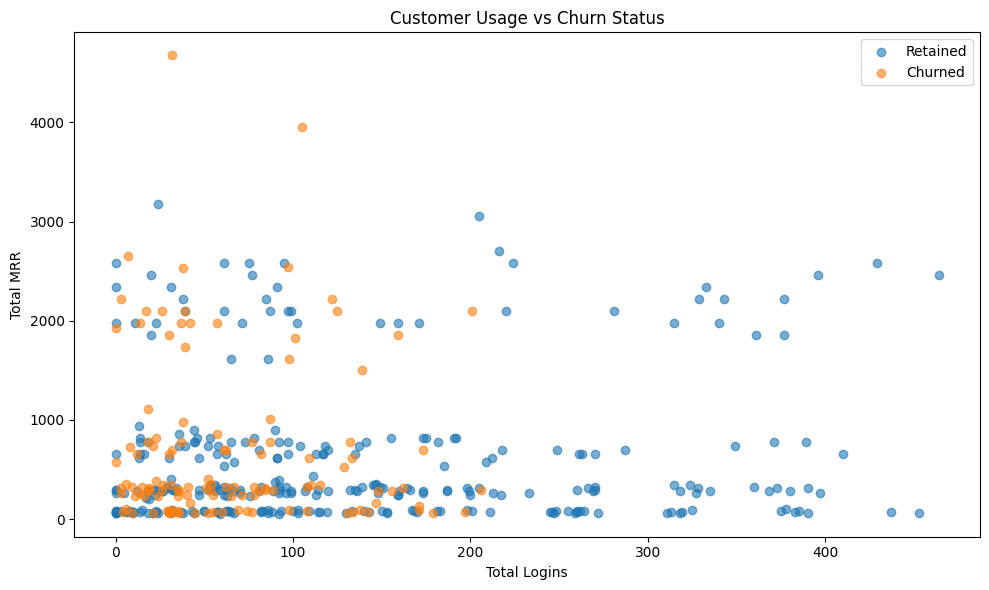

Insight: Churned customers averaged 65.2 logins, compared with 134.0 for retained customers.


In [22]:
# ============================================================
# CHART 5 — USAGE VS CHURN RELATIONSHIP
# ============================================================

plt.figure(figsize=(10, 6))

churned_data = customer_view[
    customer_view["Churn_Status"] == "Churned"
]

retained_data = customer_view[
    customer_view["Churn_Status"] == "Retained"
]

plt.scatter(
    retained_data["Total_Logins"],
    retained_data["Total_MRR"],
    label="Retained",
    alpha=0.6
)

plt.scatter(
    churned_data["Total_Logins"],
    churned_data["Total_MRR"],
    label="Churned",
    alpha=0.6
)

plt.title("Customer Usage vs Churn Status")
plt.xlabel("Total Logins")
plt.ylabel("Total MRR")
plt.legend()
plt.tight_layout()
plt.show()

churned_mean_logins = (
    churned_data["Total_Logins"].mean()
)

retained_mean_logins = (
    retained_data["Total_Logins"].mean()
)

print(
    f"Insight: Churned customers averaged "
    f"{churned_mean_logins:.1f} logins, compared with "
    f"{retained_mean_logins:.1f} for retained customers."
)

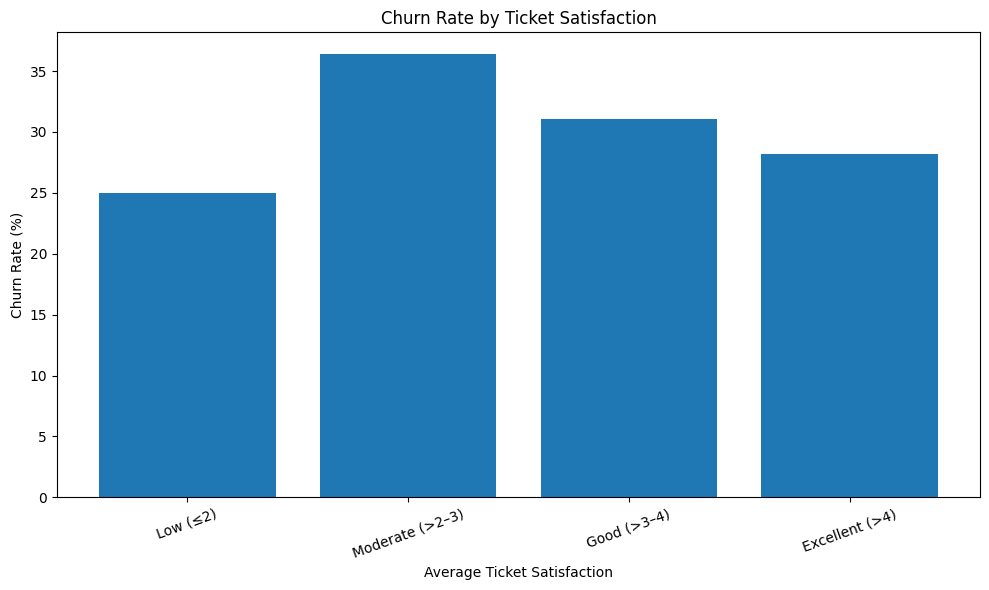

Insight: The Moderate (>2–3) satisfaction group had a 36.4% churn rate.


In [24]:

# ============================================================
# CHART 6 — TICKET SATISFACTION IMPACT
# ============================================================

customer_view["Satisfaction_Group"] = pd.cut(
    customer_view["Average_Satisfaction"],
    bins=[
        -np.inf,
        2,
        3,
        4,
        np.inf
    ],
    labels=[
        "Low (≤2)",
        "Moderate (>2–3)",
        "Good (>3–4)",
        "Excellent (>4)"
    ]
)

satisfaction_churn = (
    customer_view
    .dropna(subset=["Satisfaction_Group"])
    .groupby(
        "Satisfaction_Group",
        observed=True
    )["Churn_Status"]
    .apply(
        lambda x:
        (x == "Churned").mean() * 100
    )
    .reset_index(
        name="Churn_Rate"
    )
)

plt.figure(figsize=(10, 6))

plt.bar(
    satisfaction_churn["Satisfaction_Group"].astype(str),
    satisfaction_churn["Churn_Rate"]
)

plt.title("Churn Rate by Ticket Satisfaction")
plt.xlabel("Average Ticket Satisfaction")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

if len(satisfaction_churn) > 0:

    highest_satisfaction_churn = (
        satisfaction_churn.loc[
            satisfaction_churn["Churn_Rate"].idxmax()
        ]
    )

    print(
        f"Insight: The "
        f"{highest_satisfaction_churn['Satisfaction_Group']} "
        f"satisfaction group had a "
        f"{highest_satisfaction_churn['Churn_Rate']:.1f}% "
        f"churn rate."
    )

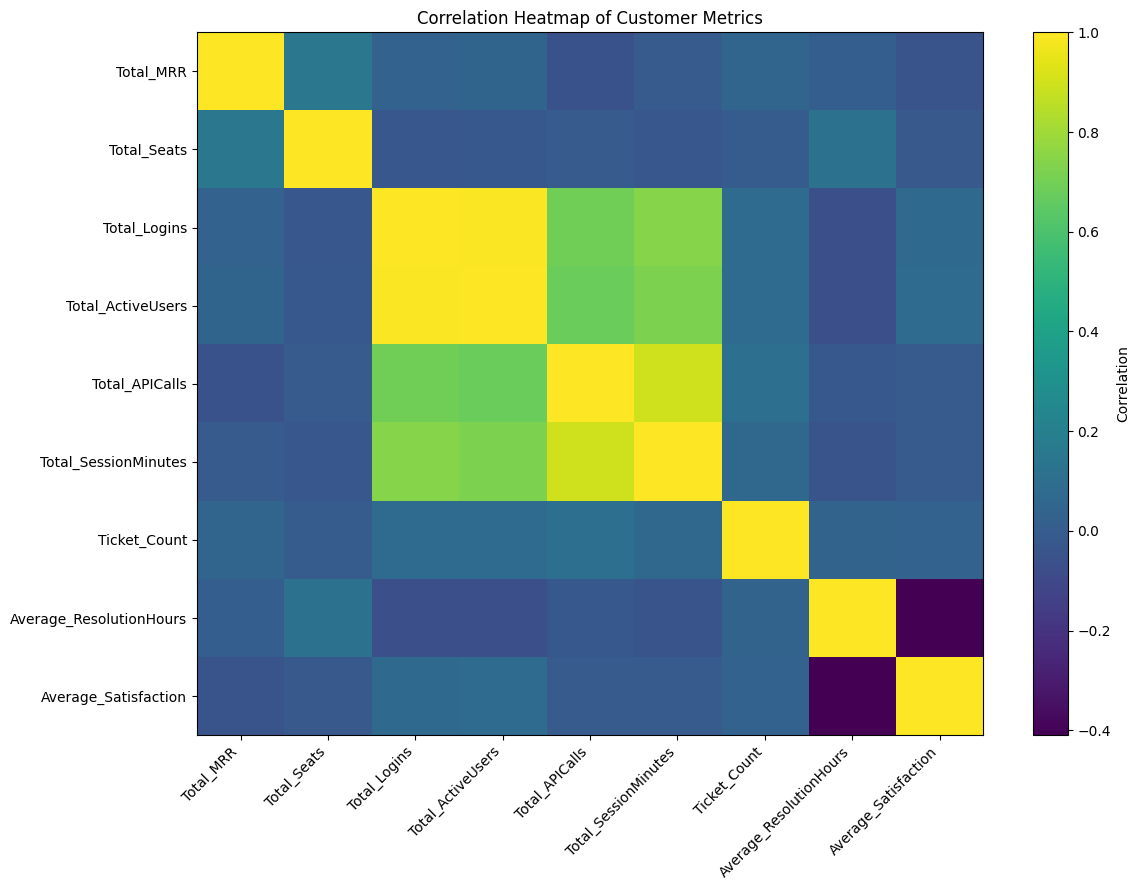

Insight: The strongest correlation was between Total_Logins and Total_ActiveUsers, with r = 0.99.


In [25]:
# ============================================================
# CHART 7 — CORRELATION HEATMAP
# ============================================================

correlation_columns = [
    "Total_MRR",
    "Total_Seats",
    "Total_Logins",
    "Total_ActiveUsers",
    "Total_APICalls",
    "Total_SessionMinutes",
    "Ticket_Count",
    "Average_ResolutionHours",
    "Average_Satisfaction"
]

correlation_matrix = (
    customer_view[
        correlation_columns
    ]
    .corr()
)

plt.figure(figsize=(12, 9))

plt.imshow(
    correlation_matrix,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title(
    "Correlation Heatmap of Customer Metrics"
)

plt.tight_layout()
plt.show()


# Find strongest meaningful relationship
corr_pairs = []

for i in range(
    len(correlation_matrix.columns)
):

    for j in range(i + 1, len(correlation_matrix.columns)):

        value = correlation_matrix.iloc[i, j]

        corr_pairs.append({
            "Variable_1":
                correlation_matrix.columns[i],
            "Variable_2":
                correlation_matrix.columns[j],
            "Correlation":
                value
        })

corr_pairs_df = pd.DataFrame(
    corr_pairs
)

corr_pairs_df["Absolute_Correlation"] = (
    corr_pairs_df["Correlation"].abs()
)

strongest_pair = corr_pairs_df.loc[
    corr_pairs_df["Absolute_Correlation"].idxmax()
]

print(
    f"Insight: The strongest correlation was between "
    f"{strongest_pair['Variable_1']} and "
    f"{strongest_pair['Variable_2']}, "
    f"with r = {strongest_pair['Correlation']:.2f}."
)


In [28]:
# ============================================================
# 9. SAVE VISUALISATION DATA
# ============================================================

churn_trend.to_csv(
    "module7_churn_trend.csv",
    index=False
)

retention_rate.to_csv(
    "module7_retention_curve.csv",
    index=False
)

# Save only if Chart 3 was successfully created
if "segment_churn" in locals():
    segment_churn.to_csv(
        "module7_churn_by_segment.csv",
        index=False
)
else:
    print(
        "\nWARNING: segment_churn was not created."
        "\nChart 3 — Churn by Segment needs to be fixed."
    )

satisfaction_churn.to_csv(
    "module7_satisfaction_churn.csv",
    index=False
)

correlation_matrix.to_csv(
    "module7_correlation_matrix.csv"
)

customer_view.to_csv(
    "module7_customer_visualisation_data.csv",
    index=False
)


# ============================================================
# 10. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 70)
print("MODULE 7 SAVE PROCESS COMPLETED")
print("=" * 70)

print("""
Visualisation outputs:

1. Churn trend over time
2. Retention curve
3. Churn by segment
4. Usage distribution
5. Usage vs churn relationship
6. Ticket satisfaction impact
7. Correlation heatmap
""")


Chart 3 — Churn by Segment needs to be fixed.

MODULE 7 SAVE PROCESS COMPLETED

Visualisation outputs:

1. Churn trend over time
2. Retention curve
3. Churn by segment
4. Usage distribution
5. Usage vs churn relationship
6. Ticket satisfaction impact
7. Correlation heatmap

